# Violence Detection — 3D-CNN + BiGRU 



##  Table of Contents
1. [Setup & Imports](#s1)
2. [Configuration & Force-Flags](#s2)
3. [Persistent State Manager — Runs Every Time](#s3)
4. [Dataset Unification](#s4)
5. [Data Cleaning & Deduplication](#s5)
6. [Balance & Split](#s6)
7. [Dataset Classes & DataLoaders](#s7)
8. [Model Definition — 3D-CNN + BiGRU](#s8)
9. [Training Gate — Skips if Already Trained](#s9)
10. [Training Curves & Overfitting](#s10)
11. [Evaluation & Metrics](#s11)
12. [Explainable AI — Grad-CAM 3D](#s12)
13. [Inference on New Videos](#s13)
14. [Experiments Sandbox](#s14)


<a id="s1"></a>
## 1.  Setup & Imports

In [29]:
!pip install grad-cam scikit-learn matplotlib seaborn tqdm --quiet


In [30]:
import os, cv2, shutil, hashlib, logging, json, time, warnings, random, traceback
from pathlib import Path
from collections import defaultdict
from datetime import datetime
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings('ignore')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[logging.FileHandler('pipeline.log'), logging.StreamHandler()]
)
log = logging.getLogger(__name__)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print(f'✅ Imports OK')
print(f'🐍 PyTorch : {torch.__version__}')
print(f'💻 CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'🎮 GPU     : {torch.cuda.get_device_name(0)}')
print(f'📍 Device  : {DEVICE}')


✅ Imports OK
🐍 PyTorch : 2.10.0+cu128
💻 CUDA    : True
🎮 GPU     : Tesla T4
📍 Device  : cuda


<a id="s2"></a>
## 2. Configuration & Force-Flags



In [31]:
# ════════════════════════════════════════════════════════════
#  ⚠️  ONLY CHANGE THESE FLAGS — everything else is automatic
# ════════════════════════════════════════════════════════════
FORCE_RETRAIN   = False   # True = always retrain, False = skip if model exists
FORCE_REPROCESS = False   # True = redo dataset unification/cleaning from scratch

CFG = {
    # ── Paths ────────────────────────────────────────────────
    'dataset_roots': [
        '/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset',
        '/kaggle/input/datasets/magicearth25/video-violence-detection-dataset',
        '/kaggle/input/datasets/marzoukhedi/data-bu-hedi',
        '/kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd',
    ],
    'unified_dir'    : '/kaggle/working/unified_dataset',
    'working_dir'    : '/kaggle/working',

    # ── Label mapping ─────────────────────────────────────────
    'fight_keywords'   : {'violence', 'fight', 'weaponized'},
    'nofight_keywords' : {'nonviolence', 'nonfight', 'normal', 'nofight'},
    'video_exts'       : {'.mp4', '.avi', '.mov', '.mkv', '.wmv', '.flv', '.webm'},

    # ── 3D-CNN + BiGRU ────────────────────────────────────────
    'num_frames'    : 16,
    'img_size'      : 112,
    'cnn_channels'  : [32, 64, 128, 256],
    'gru_hidden'    : 256,
    'gru_layers'    : 2,
    'gru_dropout'   : 0.3,
    'fc_dropout'    : 0.5,

    # ── Training ──────────────────────────────────────────────
    'epochs'        : 30,
    'batch_size'    : 8,
    'lr'            : 3e-4,
    'weight_decay'  : 1e-4,
    'label_smooth'  : 0.1,
    'patience'      : 10,
    'num_workers'   : 2,
    'grad_clip'     : 1.0,
    'warmup_epochs' : 3,

    # ── Split & Balance ───────────────────────────────────────
    'train_ratio'    : 0.8,
    'val_ratio'      : 0.1,
    'test_ratio'     : 0.1,
    'balance_50_50'  : True,
    'overfitting_gap': 0.08,

    # ── Fixed paths ───────────────────────────────────────────
    'classes'        : ['noFight', 'fight'],
    'df_path'        : '/kaggle/working/dataset_df.csv',
    'splits_path'    : '/kaggle/working/splits.json',
    'history_path'   : '/kaggle/working/training_history.json',
    'session_path'   : '/kaggle/working/session_state.json',
    'checkpoint_last': '/kaggle/working/checkpoint_last.pth',
}

# Normalisation constants (needed in multiple sections)
NORM_MEAN = [0.45, 0.45, 0.45]
NORM_STD  = [0.225, 0.225, 0.225]

print('✅ Configuration loaded')
print(f'   FORCE_RETRAIN   : {FORCE_RETRAIN}')
print(f'   FORCE_REPROCESS : {FORCE_REPROCESS}')
print(f'   Architecture    : 3D-CNN {CFG["cnn_channels"]} + BiGRU(h={CFG["gru_hidden"]},l={CFG["gru_layers"]})')
print(f'   Input           : {CFG["num_frames"]} frames × {CFG["img_size"]}px')


✅ Configuration loaded
   FORCE_RETRAIN   : False
   FORCE_REPROCESS : False
   Architecture    : 3D-CNN [32, 64, 128, 256] + BiGRU(h=256,l=2)
   Input           : 16 frames × 112px


<a id="s3"></a>
## 3. Persistent State Manager


In [32]:
# ════════════════════════════════════════════════════════════
#  SESSION STATE — read/write helpers
# ════════════════════════════════════════════════════════════

def save_session_state(updates: dict):
    """Merge updates into session_state.json on disk."""
    state = load_session_state()
    state.update(updates)
    state['last_updated'] = datetime.now().isoformat()
    with open(CFG['session_path'], 'w') as f:
        json.dump(state, f, indent=2)

def load_session_state() -> dict:
    """Load session_state.json; return empty dict if missing."""
    if os.path.exists(CFG['session_path']):
        try:
            with open(CFG['session_path']) as f:
                return json.load(f)
        except:
            return {}
    return {}

def find_best_model_on_disk() -> str | None:
    """
    Returns the path to the best saved model.
    Priority: session_state['best_model_path'] → newest model_best_*.pth
    """
    state = load_session_state()
    # 1. Explicit path in session state
    explicit = state.get('best_model_path')
    if explicit and os.path.exists(explicit):
        return explicit
    # 2. Scan for versioned model files
    working = Path(CFG['working_dir'])
    candidates = sorted(working.glob('model_best_*.pth'), key=os.path.getmtime, reverse=True)
    if candidates:
        return str(candidates[0])
    return None

def training_already_done() -> bool:
    """True if a valid best model exists on disk AND FORCE_RETRAIN is False."""
    if FORCE_RETRAIN:
        return False
    return find_best_model_on_disk() is not None

# ── Run state check ──────────────────────────────────────────
print('\n' + '═'*62)
print('  🔑 PERSISTENT SESSION STATE')
print('═'*62)

state = load_session_state()

# Show saved files
key_files = {
    'dataset_df.csv'       : CFG['df_path'],
    'splits.json'          : CFG['splits_path'],
    'training_history.json': CFG['history_path'],
    'checkpoint_last.pth'  : CFG['checkpoint_last'],
    'session_state.json'   : CFG['session_path'],
}
print('\n📁 Key files on disk:')
for label, path in key_files.items():
    exists = os.path.exists(path)
    icon = '✅' if exists else '❌'
    size = f'  ({os.path.getsize(path)/1024:.1f} KB)' if exists and os.path.isfile(path) else ''
    print(f'   {icon} {label:28s}{size}')

# Show versioned best models
working = Path(CFG['working_dir'])
best_models = sorted(working.glob('model_best_*.pth'), key=os.path.getmtime, reverse=True)
print(f'\n🏆 Saved best models ({len(best_models)} found):')
if best_models:
    for m in best_models[:5]:
        size_mb = os.path.getsize(m) / (1024*1024)
        mtime   = datetime.fromtimestamp(os.path.getmtime(m)).strftime('%Y-%m-%d %H:%M')
        print(f'   ✅ {m.name:45s} {size_mb:.1f} MB  [{mtime}]')
else:
    print('   ❌ None found — training required')

# Show session state metadata
if state:
    print(f'\n📋 Session metadata:')
    for k, v in state.items():
        if k not in ('last_updated',):
            print(f'   {k:25s}: {v}')
    print(f'   last_updated            : {state.get("last_updated", "?")}')

# Training decision
print(f'\n' + '─'*62)
_will_train = not training_already_done()
if FORCE_RETRAIN:
    print('   🔄 FORCE_RETRAIN=True  → Will retrain from scratch')
elif _will_train:
    print('   🚀 No model found      → Will run full training pipeline')
else:
    bm = find_best_model_on_disk()
    print(f'   ⏭️  Model found         → Training will be SKIPPED')
    print(f'   📂 Will load           : {Path(bm).name}')

print('═'*62)



══════════════════════════════════════════════════════════════
  🔑 PERSISTENT SESSION STATE
══════════════════════════════════════════════════════════════

📁 Key files on disk:
   ✅ dataset_df.csv                (471.6 KB)
   ✅ splits.json                   (696.8 KB)
   ✅ training_history.json         (3.7 KB)
   ✅ checkpoint_last.pth           (39145.2 KB)
   ✅ session_state.json            (0.4 KB)

🏆 Saved best models (18 found):
   ✅ model_best_20260505_173957_acc62_48.pth       12.7 MB  [2026-05-06 04:19]
   ✅ model_best_20260505_213800_acc76_81.pth       12.7 MB  [2026-05-06 04:19]
   ✅ model_best_20260506_004349_acc81_80.pth       12.7 MB  [2026-05-06 04:19]
   ✅ model_best_20260505_233448_acc81_48.pth       12.7 MB  [2026-05-06 04:19]
   ✅ model_best_20260505_180407_acc63_61.pth       12.7 MB  [2026-05-06 04:19]

📋 Session metadata:
   dataset_unified          : True
   total_videos             : 11632
   data_cleaned             : True
   clean_videos             : 7130
   s

<a id="s4"></a>
## 4. Dataset Unification



In [33]:
try:
    if os.path.exists(CFG['df_path']) and not FORCE_REPROCESS:
        print(f'⏭️  Dataset already unified — loading from disk...')
        df = pd.read_csv(CFG['df_path'])
        print(f'   ✅ {len(df)} videos loaded')
        print(df['label'].value_counts().to_string())
    else:
        if FORCE_REPROCESS:
            print('🔄 FORCE_REPROCESS=True — rebuilding from scratch...')

        def classify_folder(name, cfg):
            n = name.lower().strip()
            if n in cfg['fight_keywords']:   return 'fight'
            if n in cfg['nofight_keywords']: return 'noFight'
            return None

        def scan_datasets(roots, cfg):
            collected = defaultdict(list)
            for root in roots:
                root = Path(root)
                if not root.exists():
                    log.warning(f'⚠️  Not found: {root}'); continue
                for dirpath, _, filenames in os.walk(root):
                    label = classify_folder(Path(dirpath).name, cfg)
                    if label is None: continue
                    for fname in filenames:
                        if Path(fname).suffix.lower() in cfg['video_exts']:
                            collected[label].append(os.path.join(dirpath, fname))
            return dict(collected)

        def copy_to_unified(collected, cfg):
            for cls in cfg['classes']:
                os.makedirs(os.path.join(cfg['unified_dir'], cls), exist_ok=True)
            records = []
            for label, paths in collected.items():
                dest_dir = Path(cfg['unified_dir']) / label
                for i, src in enumerate(tqdm(paths, desc=label)):
                    src = Path(src)
                    dest = dest_dir / f'{i:06d}_{src.name}'
                    if not dest.exists():
                        try:    os.symlink(src, dest)
                        except:
                            try: shutil.copy2(src, dest)
                            except Exception as e:
                                log.warning(f'Skip {src}: {e}'); continue
                    records.append({'path': str(dest), 'label': label})
            return pd.DataFrame(records)

        collected = scan_datasets(CFG['dataset_roots'], CFG)
        print('\n📊 Scan results:')
        for label, paths in collected.items():
            print(f'   {label:10s}: {len(paths):5d} videos')

        df = copy_to_unified(collected, CFG)
        df.to_csv(CFG['df_path'], index=False)
        save_session_state({'dataset_unified': True, 'total_videos': len(df)})
        print(f'\n✅ Unification complete: {len(df)} videos')
        print(df['label'].value_counts().to_string())

except Exception as e:
    print(f'\n❌ Error section 4: {e}')
    traceback.print_exc()
    print('\n💡 Check that dataset_roots in CFG exist on your system')


⏭️  Dataset already unified — loading from disk...
   ✅ 7130 videos loaded
label
fight      4026
noFight    3104


<a id="s5"></a>
## 5. Data Cleaning & Deduplication



In [34]:
try:
    # Only clean if we just created the df (not loaded from disk)
    # We track this via session state
    _state = load_session_state()
    _already_cleaned = _state.get('data_cleaned', False) and not FORCE_REPROCESS

    if _already_cleaned:
        print('⏭️  Data already cleaned — skipping deduplication')
        print(f'   ✅ {len(df)} clean videos in memory')
    else:
        def file_hash(path, chunk=1024*1024):
            h = hashlib.md5()
            try:
                with open(path, 'rb') as f:
                    while True:
                        d = f.read(chunk)
                        if not d: break
                        h.update(d)
                return h.hexdigest()
            except: return None

        def validate_video(path, num_frames=8):
            try:
                cap = cv2.VideoCapture(str(path))
                if not cap.isOpened(): return False
                total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                cap.release()
                return total >= num_frames
            except: return False

        print('🔍 MD5 deduplication...')
        seen, to_drop = {}, []
        for idx, row in tqdm(df.iterrows(), total=len(df), desc='Hashing'):
            h = file_hash(row['path'])
            if h is None or h in seen: to_drop.append(idx)
            else: seen[h] = idx

        df = df.drop(index=to_drop).reset_index(drop=True)
        print(f'   Duplicates removed: {len(to_drop)}')

        print('🔍 Video validation...')
        valid = [validate_video(r['path'], CFG['num_frames'])
                 for _, r in tqdm(df.iterrows(), total=len(df), desc='Validating')]
        df = df[valid].reset_index(drop=True)
        print(f'   Valid videos: {len(df)}')
        print(df['label'].value_counts().to_string())

        df.to_csv(CFG['df_path'], index=False)
        save_session_state({'data_cleaned': True, 'clean_videos': len(df)})
        print(f'\n✅ Cleaned dataset saved: {CFG["df_path"]}')

except Exception as e:
    print(f'\n❌ Error section 5: {e}')
    traceback.print_exc()
    print('\n💡 Make sure df exists — re-run section 4 first')


⏭️  Data already cleaned — skipping deduplication
   ✅ 7130 clean videos in memory


<a id="s6"></a>
## 6. Balance & Split



In [35]:
try:
    if os.path.exists(CFG['splits_path']) and not FORCE_REPROCESS:
        # ── Reload saved splits ───────────────────────────────
        print('⏭️  Loading saved splits from disk (exact reproducibility)...')
        with open(CFG['splits_path']) as f:
            splits = json.load(f)

        train_df = pd.DataFrame(splits['train'])
        val_df   = pd.DataFrame(splits['val'])
        test_df  = pd.DataFrame(splits['test'])

        print(f'   ✅ Train : {len(train_df):5d} videos')
        print(f'   ✅ Val   : {len(val_df):5d} videos')
        print(f'   ✅ Test  : {len(test_df):5d} videos')
        print(f'   Seed used when created: {splits.get("seed", "?")}'  )

    else:
        # ── Create new splits ─────────────────────────────────
        if CFG['balance_50_50']:
            min_count    = df['label'].value_counts().min()
            df_balanced  = df.groupby('label').apply(
                lambda x: x.sample(min_count, random_state=SEED)
            ).reset_index(drop=True)
            print(f'⚖️  50/50 balance applied (undersampling to {min_count} each):')
        else:
            df_balanced = df.copy()

        print(df_balanced['label'].value_counts().to_string())

        train_df, temp_df = train_test_split(
            df_balanced, test_size=1-CFG['train_ratio'],
            stratify=df_balanced['label'], random_state=SEED
        )
        val_ratio_adj = CFG['val_ratio'] / (CFG['val_ratio'] + CFG['test_ratio'])
        val_df, test_df = train_test_split(
            temp_df, test_size=1-val_ratio_adj,
            stratify=temp_df['label'], random_state=SEED
        )

        # Save splits to JSON (preserves exact paths + labels)
        splits = {
            'train' : train_df.to_dict('records'),
            'val'   : val_df.to_dict('records'),
            'test'  : test_df.to_dict('records'),
            'seed'  : SEED,
            'created': datetime.now().isoformat(),
        }
        with open(CFG['splits_path'], 'w') as f:
            json.dump(splits, f, indent=2)
        save_session_state({'splits_saved': True})

        print(f'\n📊 Split saved to {CFG["splits_path"]}:')
        print(f'   Train : {len(train_df):5d}  ({len(train_df)/len(df_balanced)*100:.1f}%)')
        print(f'   Val   : {len(val_df):5d}  ({len(val_df)/len(df_balanced)*100:.1f}%)')
        print(f'   Test  : {len(test_df):5d}  ({len(test_df)/len(df_balanced)*100:.1f}%)')

    # Data leak check
    tp = set(train_df['path']); vp = set(val_df['path']); xp = set(test_df['path'])
    leaks = len(tp&vp) + len(tp&xp) + len(vp&xp)
    if leaks:
        print(f'\n⚠️  DATA LEAK DETECTED: {leaks} overlapping paths!')
    else:
        print('\n✅ No data leaks — splits are perfectly isolated')

except Exception as e:
    print(f'\n❌ Error section 6: {e}')
    traceback.print_exc()
    print('\n💡 Make sure df exists — re-run sections 4 & 5 first')


⏭️  Loading saved splits from disk (exact reproducibility)...
   ✅ Train :  4966 videos
   ✅ Val   :   621 videos
   ✅ Test  :   621 videos
   Seed used when created: 42

✅ No data leaks — splits are perfectly isolated


<a id="s7"></a>
## 7. Dataset Classes & DataLoaders



In [36]:
def get_frames(path, num_frames, img_size, augment=False):
    cap   = cv2.VideoCapture(str(path))
    total = max(1, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    idxs  = np.linspace(0, total-1, num_frames, dtype=int)

    frames, prev = [], None
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            frame = prev if prev is not None else np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            prev  = frame

        frame = frame.astype(np.float32) / 255.0
        frame = (frame - NORM_MEAN) / NORM_STD

        if augment:
            if random.random() > 0.5:
                frame = frame[:, ::-1, :].copy()
            if random.random() > 0.7:
                frame = np.clip(frame + np.random.normal(0, 0.02, frame.shape).astype(np.float32), -3, 3)
        frames.append(frame)
    cap.release()

    tensor = np.stack(frames, 0).transpose(0, 3, 1, 2)   # (T,C,H,W)
    return torch.from_numpy(tensor).float()


class ViolenceDataset(Dataset):
    def __init__(self, df, cfg, augment=False):
        self.df        = df.reset_index(drop=True)
        self.cfg       = cfg
        self.augment   = augment
        self.label_map = {'noFight': 0, 'fight': 1}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = self.label_map[row['label']]
        try:
            frames = get_frames(row['path'], self.cfg['num_frames'],
                                self.cfg['img_size'], self.augment)
        except Exception as e:
            log.warning(f'Load error {row["path"]}: {e}')
            frames = torch.zeros(self.cfg['num_frames'], 3,
                                 self.cfg['img_size'], self.cfg['img_size'])
        return frames, torch.tensor(label, dtype=torch.long)


In [37]:
try:
    train_ds = ViolenceDataset(train_df, CFG, augment=True)
    val_ds   = ViolenceDataset(val_df,   CFG, augment=False)
    test_ds  = ViolenceDataset(test_df,  CFG, augment=False)

    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                              num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                              num_workers=CFG['num_workers'], pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                              num_workers=CFG['num_workers'], pin_memory=True)

    print(f'✅ DataLoaders ready')
    print(f'   Train : {len(train_ds):5d} videos  ({len(train_loader):4d} batches)')
    print(f'   Val   : {len(val_ds):5d} videos  ({len(val_loader):4d} batches)')
    print(f'   Test  : {len(test_ds):5d} videos  ({len(test_loader):4d} batches)')

    # Quick shape test
    _fb, _lb = next(iter(train_loader))
    print(f'\n🔍 Batch shape : frames={_fb.shape}  labels={_lb.shape}')
    del _fb, _lb

except Exception as e:
    print(f'\n❌ Error section 7: {e}')
    traceback.print_exc()
    print('\n💡 Make sure train_df/val_df/test_df exist (sections 6)')


✅ DataLoaders ready
   Train :  4966 videos  ( 620 batches)
   Val   :   621 videos  (  78 batches)
   Test  :   621 videos  (  78 batches)

🔍 Batch shape : frames=torch.Size([8, 16, 3, 112, 112])  labels=torch.Size([8])


<a id="s8"></a>
## 8. Model Definition — 3D-CNN + BiGRU



In [38]:
class Conv3DBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool_kernel=(1,2,2), pool_stride=(1,2,2)):
        super().__init__()
        self.conv = nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn   = nn.BatchNorm3d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool3d(kernel_size=pool_kernel, stride=pool_stride)

    def forward(self, x):
        return self.pool(self.relu(self.bn(self.conv(x))))


class CNN3D_BiGRU(nn.Module):
    """3D-CNN + BiGRU violence detection (from scratch)."""

    def __init__(self, cfg):
        super().__init__()
        ch = cfg['cnn_channels']

        # ── 3D-CNN backbone ───────────────────────────────────
        self.block1 = Conv3DBlock(3,     ch[0], pool_kernel=(2,2,2), pool_stride=(2,2,2))
        self.block2 = Conv3DBlock(ch[0], ch[1])
        self.block3 = Conv3DBlock(ch[1], ch[2])
        self.block4 = Conv3DBlock(ch[2], ch[3])

        # ── Spatial pooling → sequence ────────────────────────
        T_out = cfg['num_frames'] // 2
        self.spatial_pool = nn.AdaptiveAvgPool3d((T_out, 1, 1))
        self.proj = nn.Sequential(
            nn.Linear(ch[3], ch[3]),
            nn.LayerNorm(ch[3]),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg['gru_dropout'])
        )

        # ── BiGRU ─────────────────────────────────────────────
        self.bigru = nn.GRU(
            input_size=ch[3], hidden_size=cfg['gru_hidden'],
            num_layers=cfg['gru_layers'], batch_first=True,
            bidirectional=True,
            dropout=cfg['gru_dropout'] if cfg['gru_layers'] > 1 else 0
        )

        # ── Classifier head ───────────────────────────────────
        gru_out = cfg['gru_hidden'] * 2
        self.classifier = nn.Sequential(
            nn.Linear(gru_out, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg['fc_dropout']),
            nn.Linear(256, 2)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm3d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.GRU):
                for name, p in m.named_parameters():
                    if 'weight' in name: nn.init.orthogonal_(p)
                    elif 'bias' in name: nn.init.constant_(p, 0)

    def forward(self, x):
        # x: (B,T,C,H,W) → permute for Conv3D
        x = x.permute(0, 2, 1, 3, 4)   # (B,C,T,H,W)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.spatial_pool(x)        # (B,C,T',1,1)
        x = x.squeeze(-1).squeeze(-1).permute(0, 2, 1)   # (B,T',C)
        x = self.proj(x)

        x, _ = self.bigru(x)            # (B,T',2H)
        x    = x[:, -1, :]             # last timestep

        return self.classifier(x)

    def get_cam_layer(self):
        return self.block4.conv


# ── Instantiate & verify ──────────────────────────────────────
try:
    model = CNN3D_BiGRU(CFG).to(DEVICE)
    total_p  = sum(p.numel() for p in model.parameters())
    train_p  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'✅ Model instantiated on {DEVICE}')
    print(f'   Parameters  : {total_p:,} total  /  {train_p:,} trainable')

    with torch.no_grad():
        _d = torch.randn(2, CFG['num_frames'], 3, CFG['img_size'], CFG['img_size']).to(DEVICE)
        _o = model(_d)
        print(f'   Forward OK  : input {tuple(_d.shape)} → output {tuple(_o.shape)}')
    del _d, _o

    # ── Loss / Optimizer / Scheduler / Scaler ─────────────────
    class LabelSmoothingCE(nn.Module):
        def __init__(self, smoothing=0.1):
            super().__init__()
            self.smoothing = smoothing
        def forward(self, pred, target):
            n = pred.size(1)
            smooth = self.smoothing / (n - 1)
            one_hot = torch.zeros_like(pred).fill_(smooth)
            one_hot.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            return -(one_hot * F.log_softmax(pred, dim=1)).sum(dim=1).mean()

    criterion = LabelSmoothingCE(CFG['label_smooth'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'],
                                  weight_decay=CFG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=CFG['lr'],
        epochs=CFG['epochs'], steps_per_epoch=len(train_loader),
        pct_start=CFG['warmup_epochs']/CFG['epochs'], anneal_strategy='cos'
    )
    scaler = GradScaler()
    print(f'\n✅ Criterion / Optimizer / Scheduler / Scaler ready')

except Exception as e:
    print(f'\n❌ Error section 8: {e}')
    traceback.print_exc()


✅ Model instantiated on cuda
   Parameters  : 3,335,650 total  /  3,335,650 trainable
   Forward OK  : input (2, 16, 3, 112, 112) → output (2, 2)

✅ Criterion / Optimizer / Scheduler / Scaler ready


<a id="s9"></a>
## 9. Training Gate

> This is the **core of the persistent workflow**.  
> - If `model_best_<timestamp>.pth` exists → loads weights + history → skips training  
> - If not → trains, saves versioned model, writes `session_state.json`  
> - Crash mid-training → checkpoint_last.pth keeps every epoch → resumes automatically


In [39]:
# ════════════════════════════════════════════════════════════
#  CHECKPOINT HELPERS
# ════════════════════════════════════════════════════════════

def save_checkpoint_last(model, optimizer, scheduler, scaler,
                         epoch, best_val_acc, history):
    """Rolling last-epoch checkpoint for crash recovery."""
    torch.save({
        'epoch'       : epoch,
        'model_state' : model.state_dict(),
        'optim_state' : optimizer.state_dict(),
        'sched_state' : scheduler.state_dict(),
        'scaler_state': scaler.state_dict(),
        'best_val_acc': best_val_acc,
        'history'     : history,
    }, CFG['checkpoint_last'])


def save_best_model(model, epoch, val_acc, history):
    """
    Save a versioned best-model file.
    Filename: model_best_<YYYYMMDD_HHMMSS>_acc<XX.XX>.pth
    Never overwrites a previous file.
    """
    ts       = datetime.now().strftime('%Y%m%d_%H%M%S')
    acc_str  = f'{val_acc*100:.2f}'.replace('.', '_')
    filename = f'model_best_{ts}_acc{acc_str}.pth'
    path     = os.path.join(CFG['working_dir'], filename)

    torch.save({
        'epoch'       : epoch,
        'model_state' : model.state_dict(),
        'best_val_acc': val_acc,
        'history'     : history,
        'cfg'         : {k: v for k, v in CFG.items()
                         if not isinstance(v, set)},   # sets not JSON-serialisable
        'classes'     : CFG['classes'],
        'norm_mean'   : NORM_MEAN,
        'norm_std'    : NORM_STD,
        'timestamp'   : datetime.now().isoformat(),
    }, path)

    # Update session state to point to this new best model
    save_session_state({
        'best_model_path' : path,
        'best_val_acc'    : val_acc,
        'best_epoch'      : epoch,
        'training_done'   : True,
    })
    print(f'   💾 Best model saved → {filename}  (val_acc={val_acc:.4f})')
    return path


def load_best_model_weights(model):
    """Load weights from the best model on disk into model."""
    path = find_best_model_on_disk()
    if path is None:
        raise FileNotFoundError('No best model found on disk.')
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    return ckpt


def load_checkpoint_last(model, optimizer, scheduler, scaler):
    """Restore last-epoch checkpoint for mid-training crash recovery."""
    ckpt = torch.load(CFG['checkpoint_last'], map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optim_state'])
    scheduler.load_state_dict(ckpt['sched_state'])
    scaler.load_state_dict(ckpt['scaler_state'])
    return ckpt['epoch'] + 1, ckpt['best_val_acc'], ckpt['history']


In [40]:
# ════════════════════════════════════════════════════════════
#  TRAINING FUNCTIONS
# ════════════════════════════════════════════════════════════

def train_one_epoch(model, loader, optimizer, criterion, scheduler, scaler, device, clip):
    model.train()
    total_loss = correct = total = 0
    for frames, labels in tqdm(loader, desc='Train', leave=False):
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            out  = model(frames)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer); scaler.update()
        scheduler.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    for frames, labels in tqdm(loader, desc='Val  ', leave=False):
        frames, labels = frames.to(device), labels.to(device)
        with autocast():
            out  = model(frames)
            loss = criterion(out, labels)
        total_loss += loss.item() * labels.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss/total, correct/total


In [41]:
# ════════════════════════════════════════════════════════════
#  TRAINING GATE
# ════════════════════════════════════════════════════════════
try:
    if training_already_done():
        # ── SKIP — load from disk ─────────────────────────────
        print('⏭️  Training SKIPPED — model already exists on disk')
        print('\n🔄 Loading model weights + history...')

        ckpt = load_best_model_weights(model)
        best_val_acc = ckpt.get('best_val_acc', 0.0)
        best_epoch   = ckpt.get('epoch', '?')
        model.eval()
        print(f'   ✅ Weights loaded from  : {Path(find_best_model_on_disk()).name}')
        print(f'   ✅ Best val acc         : {best_val_acc:.4f}  (epoch {best_epoch})')

        # Load history
        if os.path.exists(CFG['history_path']):
            with open(CFG['history_path']) as f:
                history = json.load(f)
            print(f'   ✅ Training history     : {len(history["train_loss"])} epochs')
        elif 'history' in ckpt:
            history = ckpt['history']
            print(f'   ✅ Training history     : {len(history["train_loss"])} epochs (from ckpt)')
        else:
            history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
            print('   ⚠️  No history found — curves will be empty')

        print('\n✅ Ready for evaluation / XAI / inference — jump to Section 10')

    else:
        # ── TRAIN ─────────────────────────────────────────────
        start_epoch  = 0
        best_val_acc = 0.0
        best_epoch   = 0
        patience_cnt = 0
        history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}

        # Resume from last checkpoint if crash recovery
        if os.path.exists(CFG['checkpoint_last']) and not FORCE_RETRAIN:
            print(f'🔄 Last checkpoint found — resuming from crash...')
            try:
                start_epoch, best_val_acc, history = load_checkpoint_last(
                    model, optimizer, scheduler, scaler)
                best_epoch = start_epoch - 1
                print(f'   ✅ Resuming from epoch {start_epoch}  (best val={best_val_acc:.4f})')
            except Exception as e:
                print(f'   ⚠️  Checkpoint unreadable ({e}) — starting from scratch')
                start_epoch = 0
        else:
            if FORCE_RETRAIN:
                print(f'🔄 FORCE_RETRAIN=True — training from scratch')
            else:
                print(f'🚀 Training from scratch ({CFG["epochs"]} epochs)')

        print(f'\n{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8} | LR')
        print('─' * 70)

        for epoch in range(start_epoch, CFG['epochs']):
            t0 = time.time()
            tl, ta = train_one_epoch(model, train_loader, optimizer, criterion,
                                     scheduler, scaler, DEVICE, CFG['grad_clip'])
            vl, va = evaluate(model, val_loader, criterion, DEVICE)
            lr_now  = optimizer.param_groups[0]['lr']
            elapsed = time.time() - t0

            history['train_loss'].append(tl)
            history['train_acc'].append(ta)
            history['val_loss'].append(vl)
            history['val_acc'].append(va)
            history['lr'].append(lr_now)

            gap  = ta - va
            flag = ' ⚠️OVERFIT' if gap > CFG['overfitting_gap'] else ''
            print(f'{epoch+1:>6} | {tl:>10.4f} | {ta:>9.4f} | {vl:>8.4f} | {va:>8.4f} | {lr_now:.2e}{flag}  [{elapsed:.0f}s]')

            # ── Save last checkpoint every epoch (crash safety) ─
            save_checkpoint_last(model, optimizer, scheduler, scaler,
                                 epoch, best_val_acc, history)

            # ── Save history every epoch ──────────────────────
            with open(CFG['history_path'], 'w') as f:
                json.dump(history, f, indent=2)

            # ── Save versioned best model ─────────────────────
            if va > best_val_acc:
                best_val_acc = va
                best_epoch   = epoch + 1
                patience_cnt = 0
                save_best_model(model, epoch+1, va, history)
            else:
                patience_cnt += 1

            if patience_cnt >= CFG['patience']:
                print(f'\n⏹️  Early stopping at epoch {epoch+1}')
                break

        print(f'\n✅ Training complete')
        print(f'   Best val_acc : {best_val_acc:.4f}  (epoch {best_epoch})')
        print(f'   Model saved  : {Path(find_best_model_on_disk()).name}')

except KeyboardInterrupt:
    print('\n⏸️  Training interrupted — checkpoint_last.pth is up to date')
    print('   Re-run this cell to resume automatically')
except Exception as e:
    print(f'\n❌ Error during training: {e}')
    traceback.print_exc()
    print('\n💡 checkpoint_last.pth is saved after every epoch.')
    print('   Re-run section 8 (model def) then this cell to resume.')


⏭️  Training SKIPPED — model already exists on disk

🔄 Loading model weights + history...
   ✅ Weights loaded from  : model_best_20260506_032622_acc86_15.pth
   ✅ Best val acc         : 0.8615  (epoch 30)
   ✅ Training history     : 30 epochs

✅ Ready for evaluation / XAI / inference — jump to Section 10


<a id="s10"></a>
## 10. Training Curves & Overfitting Dashboard

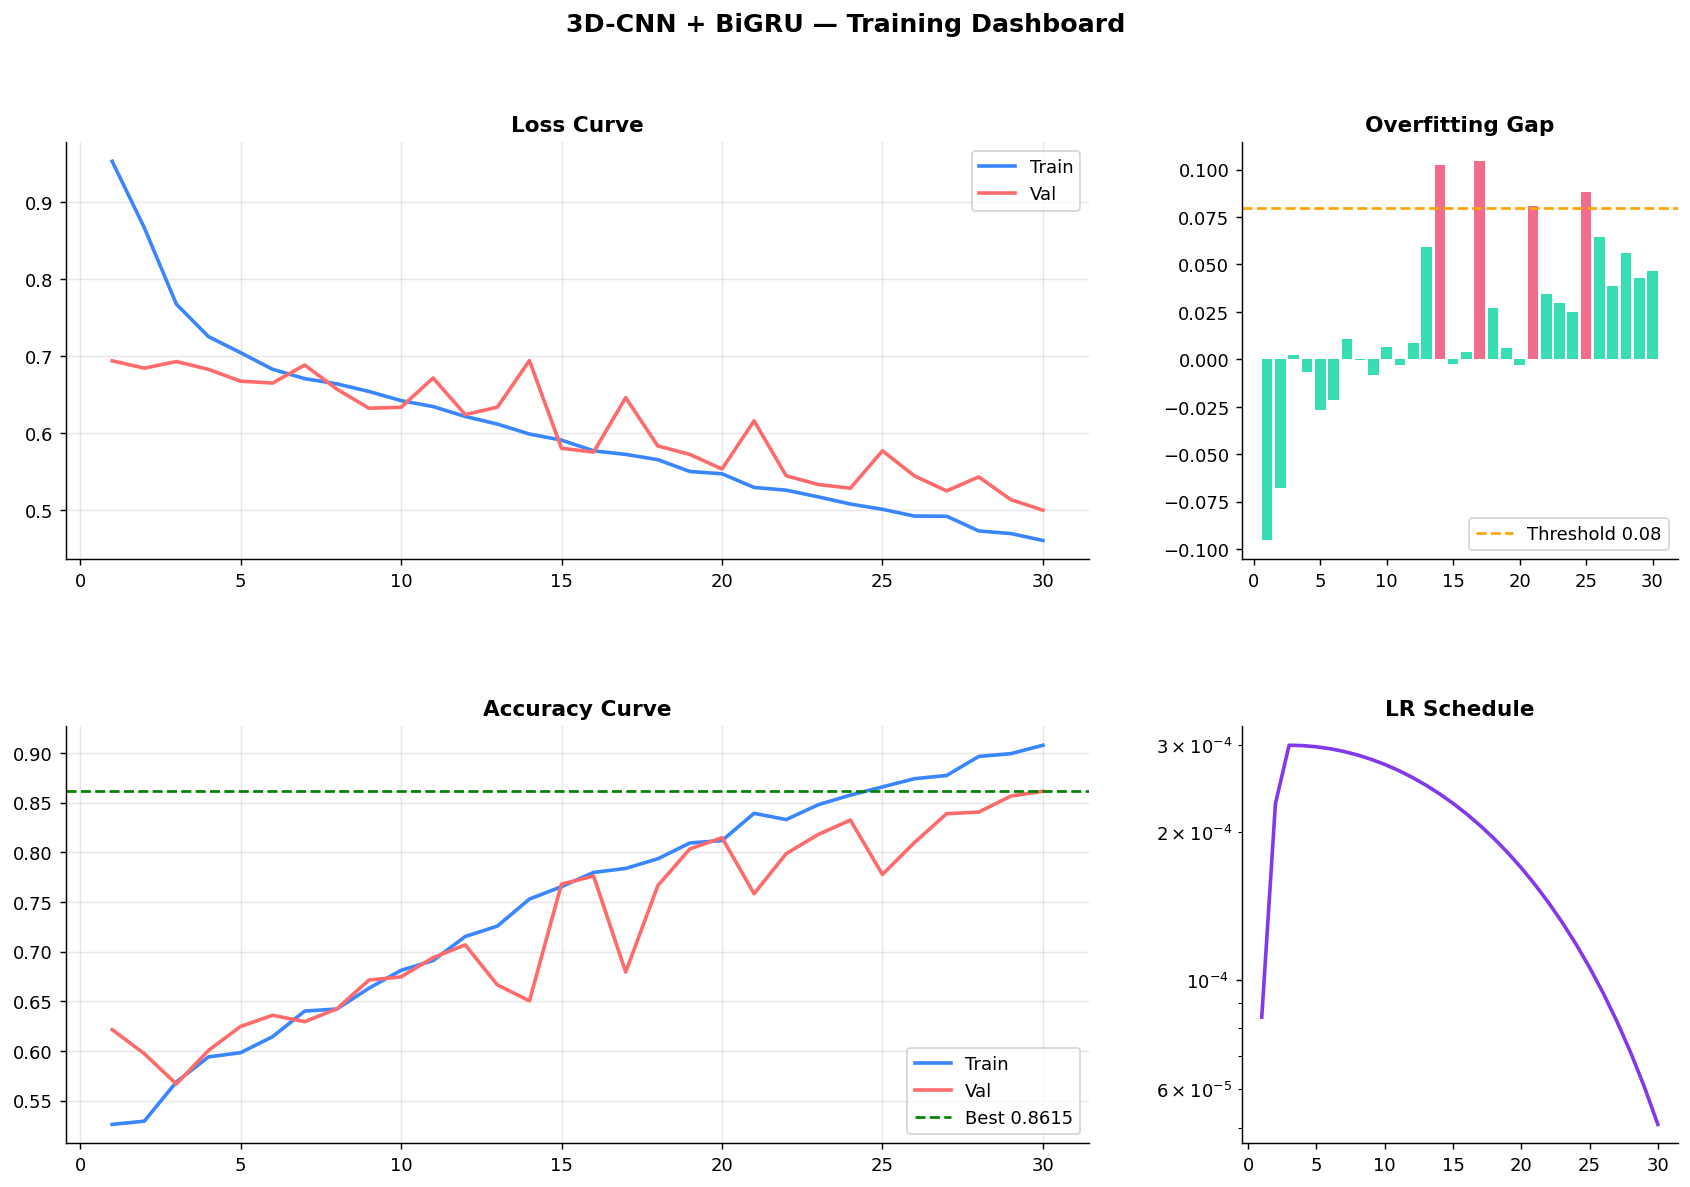

   Best val_acc      : 0.8615  (epoch 30)
   Overfit epochs    : [14, 17, 21, 25]


In [42]:
try:
    if 'history' not in dir() or not history.get('train_loss'):
        if os.path.exists(CFG['history_path']):
            with open(CFG['history_path']) as f:
                history = json.load(f)
            print(f'✅ History loaded from disk  ({len(history["train_loss"])} epochs)')
        else:
            raise RuntimeError('history not found — run section 9 first')

    E   = range(1, len(history['train_loss'])+1)
    gap = np.array(history['train_acc']) - np.array(history['val_acc'])

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(E, history['train_loss'], label='Train', color='#3A86FF', lw=2)
    ax1.plot(E, history['val_loss'],   label='Val',   color='#FF6B6B', lw=2)
    ax1.set_title('Loss Curve', fontweight='bold'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0:2])
    ax2.plot(E, history['train_acc'], label='Train', color='#3A86FF', lw=2)
    ax2.plot(E, history['val_acc'],   label='Val',   color='#FF6B6B', lw=2)
    if 'best_val_acc' in dir() and best_val_acc:
        ax2.axhline(best_val_acc, color='green', lw=1.5, ls='--',
                    label=f'Best {best_val_acc:.4f}')
    ax2.set_title('Accuracy Curve', fontweight='bold'); ax2.legend(); ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[0, 2])
    colors = ['#EF476F' if g > CFG['overfitting_gap'] else '#06D6A0' for g in gap]
    ax3.bar(E, gap, color=colors, alpha=0.8)
    ax3.axhline(CFG['overfitting_gap'], color='orange', ls='--',
                label=f'Threshold {CFG["overfitting_gap"]}')
    ax3.set_title('Overfitting Gap', fontweight='bold'); ax3.legend()

    ax4 = fig.add_subplot(gs[1, 2])
    ax4.plot(E, history['lr'], color='#8338EC', lw=2)
    ax4.set_title('LR Schedule', fontweight='bold'); ax4.set_yscale('log')

    plt.suptitle('3D-CNN + BiGRU — Training Dashboard', fontsize=14, fontweight='bold')
    plt.savefig('/kaggle/working/training_dashboard.png', bbox_inches='tight')
    plt.show()

    of_ep = [i+1 for i,g in enumerate(gap) if g > CFG['overfitting_gap']]
    print(f'   Best val_acc      : {max(history["val_acc"]):.4f}  (epoch {int(np.argmax(history["val_acc"]))+1})')
    print(f'   Overfit epochs    : {of_ep if of_ep else "None ✅"}')

except Exception as e:
    print(f'\n❌ Error section 10: {e}')
    traceback.print_exc()


<a id="s11"></a>
## 11. Evaluation & Metrics



In [43]:
# ── Auto-load model if needed ─────────────────────────────────
def ensure_model_loaded():
    """Load the best model from disk if not already in memory & eval mode."""
    global model
    bm = find_best_model_on_disk()
    if bm is None:
        print('❌ No model found on disk — run section 9 (training) first')
        return False
    try:
        ckpt = torch.load(bm, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        model.eval()
        print(f'✅ Model loaded : {Path(bm).name}')
        print(f'   val_acc      : {ckpt.get("best_val_acc", "?"):.4f}  '
              f'epoch {ckpt.get("epoch", "?")}')
        return True
    except Exception as e:
        print(f'❌ Failed to load model: {e}')
        traceback.print_exc()
        return False

print('🔄 Loading best model for evaluation...')
_loaded = ensure_model_loaded()


🔄 Loading best model for evaluation...
✅ Model loaded : model_best_20260506_032622_acc86_15.pth
   val_acc      : 0.8615  epoch 30


In [44]:
try:
    if not _loaded:
        raise RuntimeError('Model not loaded — see message above')

    @torch.no_grad()
    def collect_predictions(model, loader, device):
        preds, labels_all, probs = [], [], []
        model.eval()
        for frames, lbs in tqdm(loader, desc='Predicting'):
            frames = frames.to(device)
            with autocast():
                out = model(frames)
            probs.extend(torch.softmax(out, 1)[:, 1].cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(lbs.numpy())
        return np.array(labels_all), np.array(preds), np.array(probs)

    val_labels, val_preds, val_probs = collect_predictions(model, val_loader, DEVICE)
    print(f'✅ Validation predictions collected  ({len(val_labels)} samples)')

except Exception as e:
    print(f'\n❌ Error: {e}')
    traceback.print_exc()
    print('\n💡 Make sure val_loader exists (re-run section 7)')


Predicting:   0%|          | 0/78 [00:00<?, ?it/s]

✅ Validation predictions collected  (621 samples)


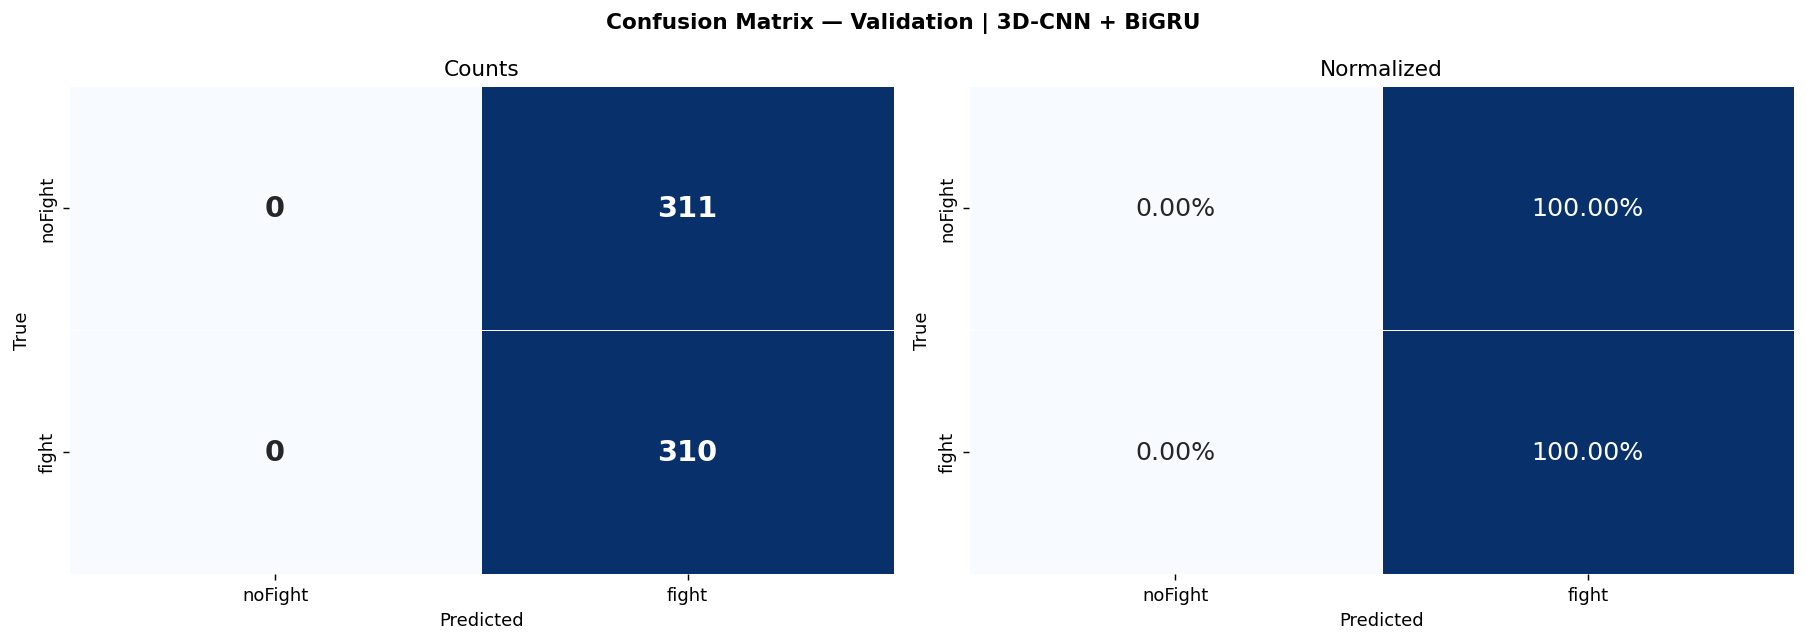

              precision    recall  f1-score   support

     noFight     0.0000    0.0000    0.0000       311
       fight     0.4992    1.0000    0.6660       310

    accuracy                         0.4992       621
   macro avg     0.2496    0.5000    0.3330       621
weighted avg     0.2492    0.4992    0.3324       621

  AUC-ROC     : 0.5000
  AUC-PR      : 0.4992
  Sensitivity : 1.0000
  Specificity : 0.0000


In [45]:
try:
    cm      = confusion_matrix(val_labels, val_preds)
    tn,fp,fn,tp = cm.ravel()
    auc_roc = roc_auc_score(val_labels, val_probs)
    auc_pr  = average_precision_score(val_labels, val_probs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Confusion Matrix — Validation | 3D-CNN + BiGRU', fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CFG['classes'], yticklabels=CFG['classes'],
                ax=axes[0], linewidths=.5, cbar=False, annot_kws={'size':16,'weight':'bold'})
    axes[0].set_title('Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    cm_n = cm.astype(float)/cm.sum(axis=1,keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CFG['classes'], yticklabels=CFG['classes'],
                ax=axes[1], linewidths=.5, cbar=False, annot_kws={'size':14})
    axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    plt.tight_layout()
    plt.savefig('/kaggle/working/val_confusion_matrix.png', bbox_inches='tight')
    plt.show()

    print(classification_report(val_labels, val_preds, target_names=CFG['classes'], digits=4))
    print(f'  AUC-ROC     : {auc_roc:.4f}')
    print(f'  AUC-PR      : {auc_pr:.4f}')
    print(f'  Sensitivity : {tp/(tp+fn):.4f}')
    print(f'  Specificity : {tn/(tn+fp):.4f}')

except Exception as e:
    print(f'\n❌ Error (confusion matrix): {e}')
    traceback.print_exc()


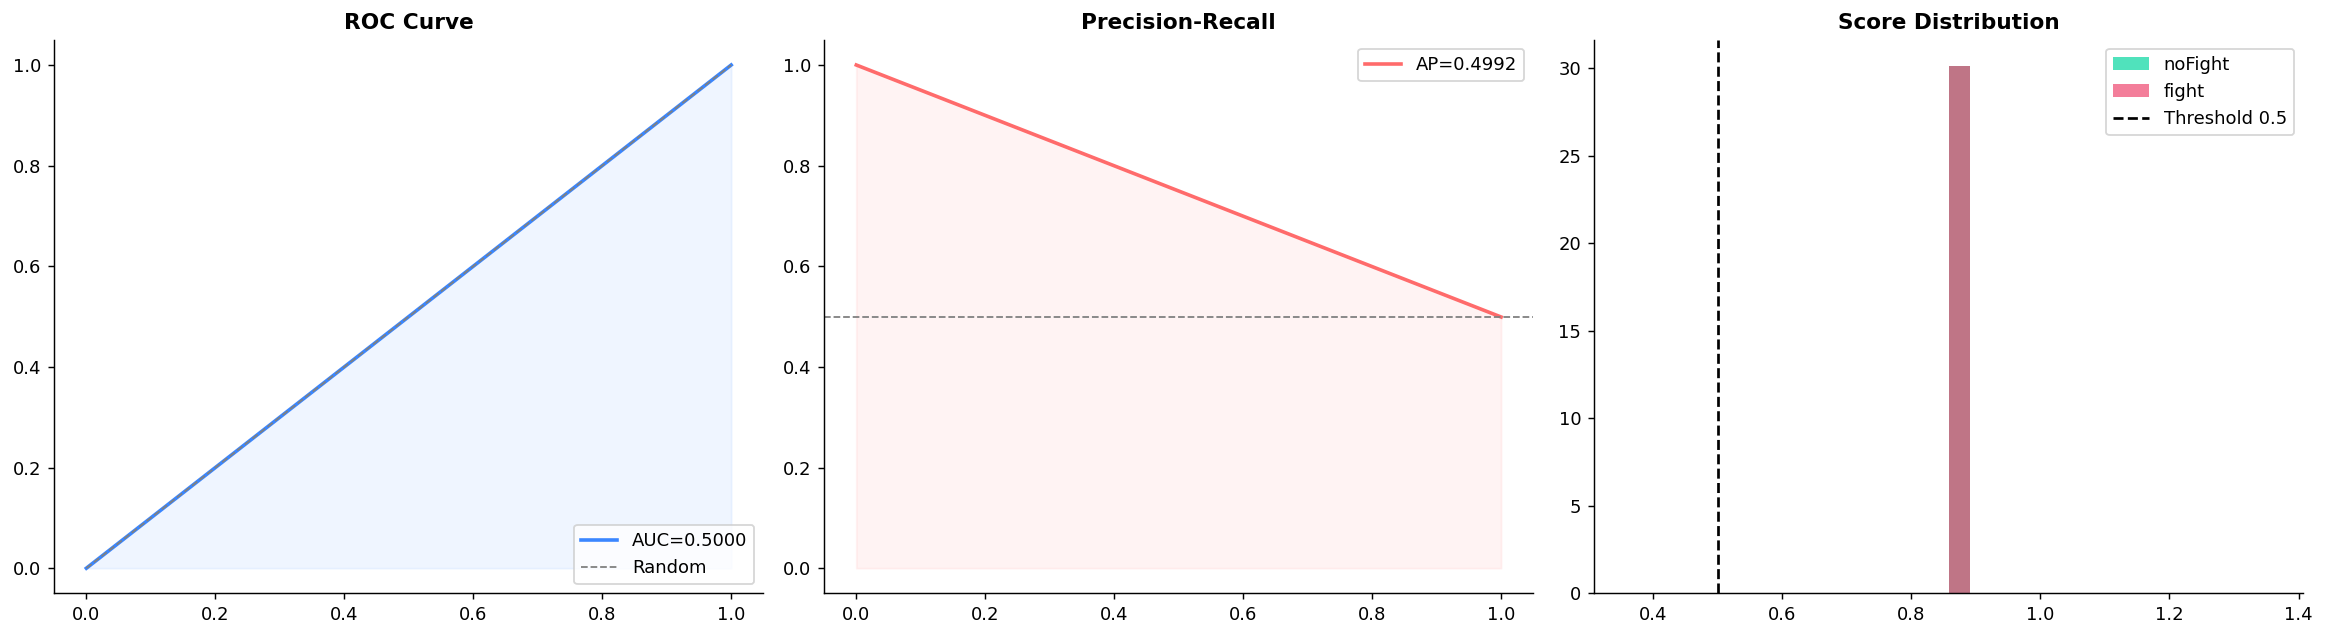

In [46]:
try:
    fpr,tpr,_    = roc_curve(val_labels, val_probs)
    prec,rec,_   = precision_recall_curve(val_labels, val_probs)
    v_probs      = val_probs[val_labels==1]
    nv_probs     = val_probs[val_labels==0]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(fpr,tpr,color='#3A86FF',lw=2,label=f'AUC={auc_roc:.4f}')
    axes[0].plot([0,1],[0,1],color='gray',lw=1,ls='--',label='Random')
    axes[0].fill_between(fpr,tpr,alpha=0.08,color='#3A86FF')
    axes[0].set_title('ROC Curve',fontweight='bold'); axes[0].legend(loc='lower right')

    axes[1].plot(rec,prec,color='#FF6B6B',lw=2,label=f'AP={auc_pr:.4f}')
    axes[1].axhline(val_labels.mean(),color='gray',ls='--',lw=1)
    axes[1].fill_between(rec,prec,alpha=0.08,color='#FF6B6B')
    axes[1].set_title('Precision-Recall',fontweight='bold'); axes[1].legend()

    axes[2].hist(nv_probs,bins=30,alpha=0.7,color='#06D6A0',label='noFight',density=True)
    axes[2].hist(v_probs, bins=30,alpha=0.7,color='#EF476F',label='fight',  density=True)
    axes[2].axvline(0.5,color='black',lw=1.5,ls='--',label='Threshold 0.5')
    axes[2].set_title('Score Distribution',fontweight='bold'); axes[2].legend()

    plt.tight_layout()
    plt.savefig('/kaggle/working/roc_pr_score_dist.png', bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'\n❌ Error (ROC/PR curves): {e}')
    traceback.print_exc()
    print('\n💡 Make sure val_labels/val_probs/auc_roc/auc_pr are defined')


In [47]:
try:
    test_labels, test_preds, test_probs = collect_predictions(model, test_loader, DEVICE)
    cm_t = confusion_matrix(test_labels, test_preds)
    tn2,fp2,fn2,tp2 = cm_t.ravel()
    test_acc  = (tp2+tn2)/len(test_labels)
    test_auc  = roc_auc_score(test_labels, test_probs)
    test_ap   = average_precision_score(test_labels, test_probs)

    print('\n' + '═'*58)
    print('  🧪 FINAL RESULTS — TEST SET')
    print('═'*58)
    print(f'  Accuracy    : {test_acc:.4f}')
    print(f'  AUC-ROC     : {test_auc:.4f}')
    print(f'  AUC-PR      : {test_ap:.4f}')
    print(f'  Sensitivity : {tp2/(tp2+fn2):.4f}')
    print(f'  Specificity : {tn2/(tn2+fp2):.4f}')
    print('═'*58)
    print(classification_report(test_labels, test_preds, target_names=CFG['classes'], digits=4))

    save_session_state({'test_acc': float(test_acc), 'test_auc': float(test_auc)})

except Exception as e:
    print(f'\n❌ Error (test set eval): {e}')
    traceback.print_exc()
    print('\n💡 Make sure test_loader and model are available (sections 7 & 9)')


Predicting:   0%|          | 0/78 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════
  🧪 FINAL RESULTS — TEST SET
══════════════════════════════════════════════════════════
  Accuracy    : 0.5008
  AUC-ROC     : 0.5000
  AUC-PR      : 0.5008
  Sensitivity : 1.0000
  Specificity : 0.0000
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     noFight     0.0000    0.0000    0.0000       310
       fight     0.5008    1.0000    0.6674       311

    accuracy                         0.5008       621
   macro avg     0.2504    0.5000    0.3337       621
weighted avg     0.2508    0.5008    0.3342       621



<a id="s12"></a>
## 12.  Explainable AI — Grad-CAM 3D

In [84]:
import torch.nn.functional as F

try:
    _loaded = ensure_model_loaded()
    NORM_MEAN_NP = np.array(NORM_MEAN)
    NORM_STD_NP  = np.array(NORM_STD)

    def denormalize(t):
        img = t.cpu().numpy().transpose(1, 2, 0)
        return np.clip(img * NORM_STD_NP + NORM_MEAN_NP, 0, 1).astype(np.float32)

    def compute_gradcam_3d(model, clip_tensor, target_class=None):
        model.eval()
        model.bigru.train()

        cam_layer = model.get_cam_layer()
        activation = {}

        def fwd_hook(m, i, o):
            o.retain_grad()          # ← forcer la rétention du gradient
            activation['f'] = o

        h_fwd = cam_layer.register_forward_hook(fwd_hook)

        clip  = clip_tensor.to(DEVICE)

        with torch.enable_grad():    # ← garantir que grad est actif même si appelé sous no_grad
            logit = model(clip)

            if target_class is None:
                target_class = logit.argmax(1).item()

            model.zero_grad()
            logit[0, target_class].backward()

        h_fwd.remove()

        if 'f' not in activation:
            raise RuntimeError("Activation non capturée")

        act = activation['f']

        if act.grad is None:
            raise RuntimeError(
                "act.grad est None — retain_grad() n'a pas fonctionné.\n"
                f"   act.requires_grad = {act.requires_grad}\n"
                f"   act.shape         = {act.shape}")

        grd = act.grad.detach()   # (1, C, T', H', W')
        act = act.detach()

        print(f"  ✅ grad max={grd.abs().max():.6f}  act max={act.abs().max():.6f}")

        w   = grd.mean(dim=(3, 4), keepdim=True)
        cam = F.relu((w * act).sum(dim=1)).squeeze(0)
        cam = cam.cpu().numpy()

        print(f"  ✅ cam max={cam.max():.6f}  cam min={cam.min():.6f}")

        H = W = CFG['img_size']
        heatmaps_t = []
        for t in range(cam.shape[0]):
            h = cv2.resize(cam[t], (W, H))
            if h.max() > 0:
                h = (h - h.min()) / (h.max() - h.min() + 1e-8)
            heatmaps_t.append(h)

        T = clip_tensor.shape[1]
        full = []
        for idx in np.linspace(0, len(heatmaps_t) - 1, T):
            i0    = int(np.floor(idx))
            i1    = min(int(np.ceil(idx)), len(heatmaps_t) - 1)
            alpha = idx - i0
            full.append((1 - alpha) * heatmaps_t[i0] + alpha * heatmaps_t[i1])

        probs = logit.softmax(1)[0].detach().cpu().numpy()
        return full, target_class, probs


    def show_gradcam(video_idx, dataset, frames_to_show=None):
        if frames_to_show is None:
            frames_to_show = list(range(0, CFG['num_frames'],
                                        max(1, CFG['num_frames'] // 5)))[:5]

        frames, label = dataset[video_idx]
        heatmaps, pred_cls, probs = compute_gradcam_3d(model, frames.unsqueeze(0))

        true_name = CFG['classes'][label.item()]
        pred_name = CFG['classes'][pred_cls]
        conf      = probs[pred_cls]
        color     = 'green' if true_name == pred_name else 'red'

        fig, axes = plt.subplots(2, len(frames_to_show),
                                 figsize=(3.5 * len(frames_to_show), 6))
        fig.suptitle(
            f'Grad-CAM | True: {true_name} | Pred: {pred_name} ({conf:.2%})',
            fontsize=13, fontweight='bold', color=color)

        for col, t in enumerate(frames_to_show):
            if t >= CFG['num_frames']:
                continue
            img  = denormalize(frames[t])
            heat = heatmaps[t]

            axes[0, col].imshow(img)
            axes[0, col].set_title(f'Frame {t}', fontsize=9)
            axes[0, col].axis('off')

            rgb = cv2.cvtColor(
                cv2.applyColorMap((heat * 255).astype(np.uint8), cv2.COLORMAP_JET),
                cv2.COLOR_BGR2RGB).astype(np.float32) / 255
            overlay = np.clip(0.55 * img + 0.45 * rgb, 0, 1)
            axes[1, col].imshow(overlay)
            axes[1, col].axis('off')

        axes[0, 0].set_ylabel('Original', fontsize=10)
        axes[1, 0].set_ylabel('Grad-CAM', fontsize=10)
        plt.tight_layout()
        plt.savefig(f'/kaggle/working/gradcam_{video_idx}.png', bbox_inches='tight')
        plt.show()
        print(f'  ✅ Saved: gradcam_{video_idx}.png')

    print('✅ Grad-CAM prêt')
    print('   Usage: show_gradcam(idx, test_ds)')

except Exception as e:
    print(f'\n❌ Erreur Grad-CAM setup: {e}')
    import traceback; traceback.print_exc()

✅ Model loaded : model_best_20260506_032622_acc86_15.pth
   val_acc      : 0.8615  epoch 30
✅ Grad-CAM prêt
   Usage: show_gradcam(idx, test_ds)


🔴 Grad-CAM — FIGHT example (position 0):
  ✅ grad max=0.000075  act max=32.744659
  ✅ cam max=0.001203  cam min=0.000000


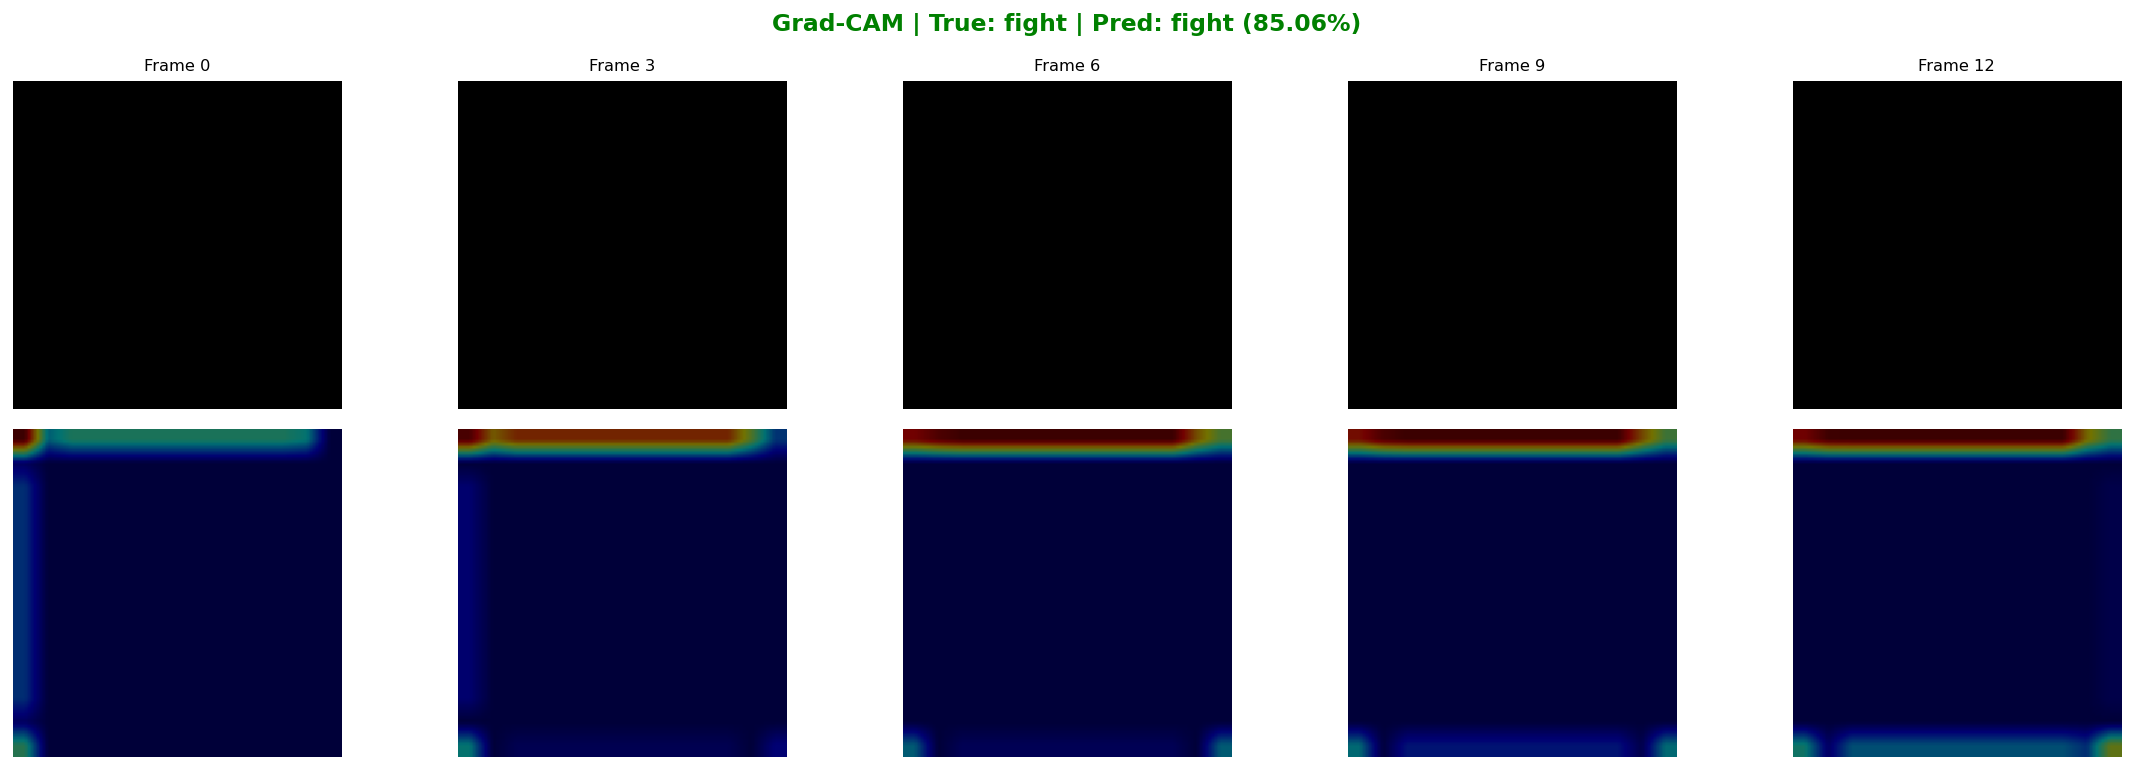

  ✅ Saved: gradcam_0.png
🟢 Grad-CAM — noFight example (position 1):
  ✅ grad max=0.000066  act max=32.744659
  ✅ cam max=0.001009  cam min=0.000000


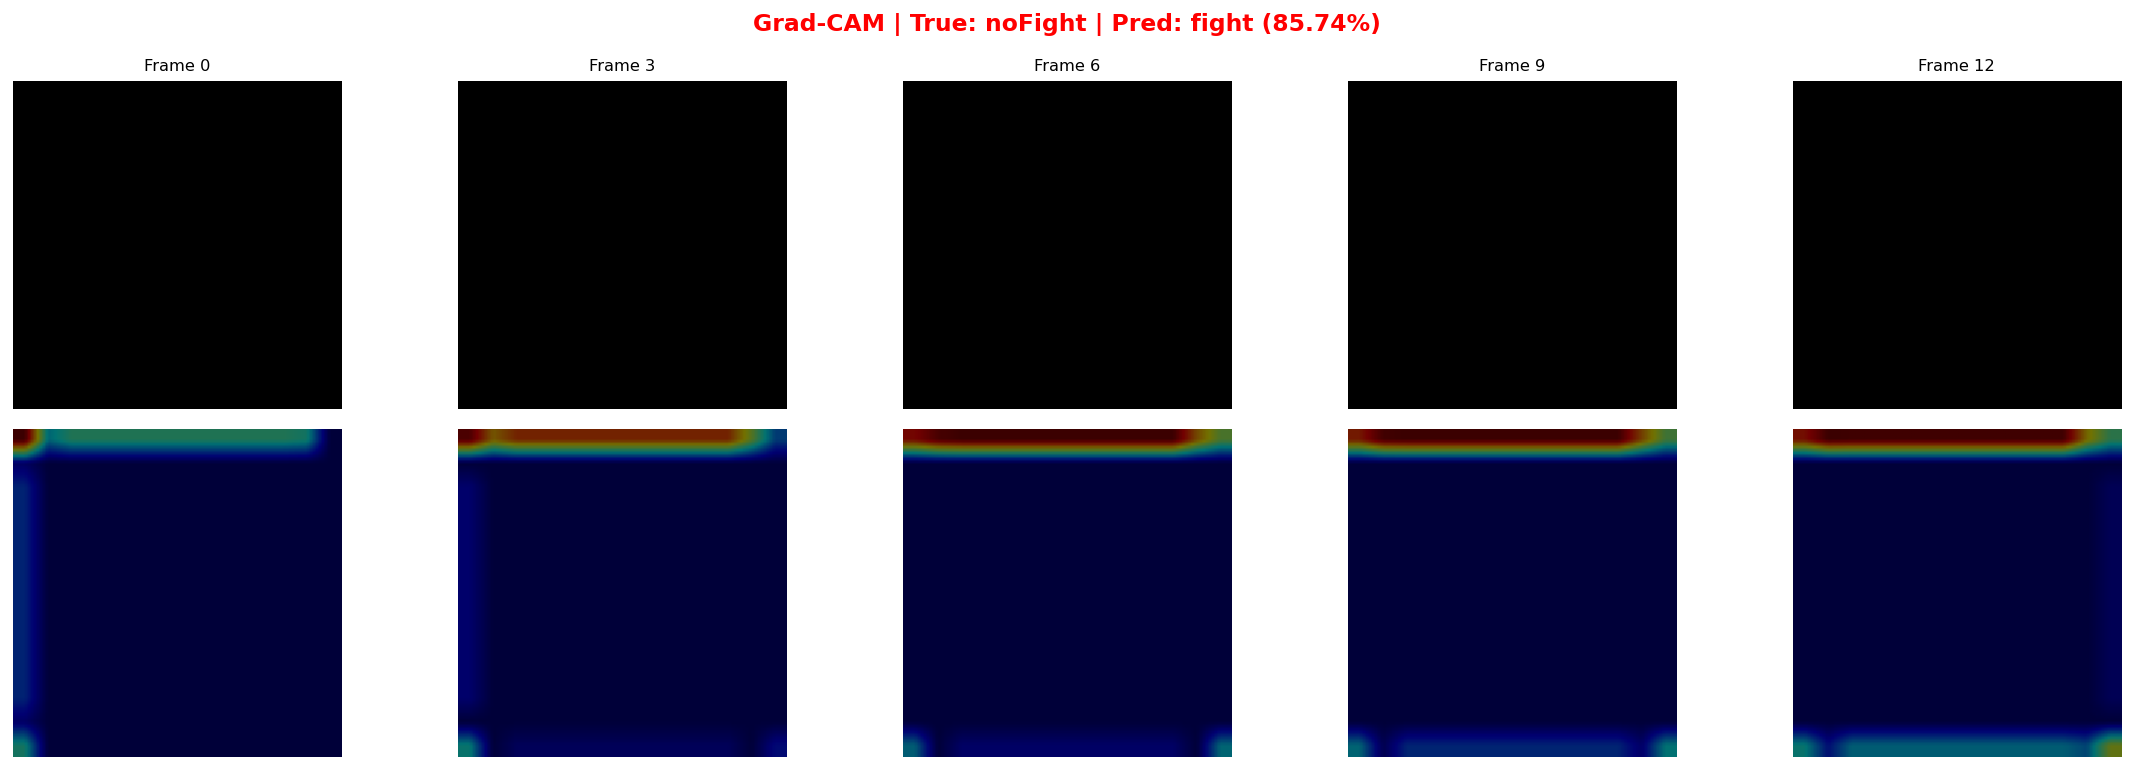

  ✅ Saved: gradcam_1.png


In [85]:
try:
    if not _loaded:
        raise RuntimeError('Model not loaded')

    fight_positions   = test_ds.df.reset_index(drop=True)
    fight_positions   = fight_positions[fight_positions['label'] == 'fight']
    nofight_positions = test_ds.df.reset_index(drop=True)
    nofight_positions = nofight_positions[nofight_positions['label'] == 'noFight']

    if len(fight_positions) == 0:
        raise ValueError("Aucune vidéo 'fight' dans test_ds")
    if len(nofight_positions) == 0:
        raise ValueError("Aucune vidéo 'noFight' dans test_ds")

    _fight_idx   = fight_positions.index[0]
    _nofight_idx = nofight_positions.index[0]

    print(f'🔴 Grad-CAM — FIGHT example (position {_fight_idx}):')
    show_gradcam(_fight_idx, test_ds)

    print(f'🟢 Grad-CAM — noFight example (position {_nofight_idx}):')
    show_gradcam(_nofight_idx, test_ds)

except Exception as e:
    print(f'\n❌ Erreur: {e}')
    import traceback; traceback.print_exc()
    print(f'\n💡 Debug:')
    print(f'   test_ds taille  : {len(test_ds)}')
    print(f'   Labels présents : {test_ds.df["label"].value_counts().to_dict()}')
    print('\n💡 Forcer manuellement : show_gradcam(0, test_ds)')

<a id="s13"></a>
## 13. Inference on New Videos



In [50]:
def predict_video(video_path, model=None, cfg=CFG, device=DEVICE, threshold=0.5):
    """
    Run inference on a single video file.
    Returns dict with label, confidence, and per-frame probabilities.
    """
    if model is None:
        raise ValueError('Pass model= argument or ensure model is loaded (ensure_model_loaded())')

    model.eval()
    try:
        frames = get_frames(video_path, cfg['num_frames'], cfg['img_size'], augment=False)
    except Exception as e:
        return {'error': str(e)}

    with torch.no_grad():
        clip   = frames.unsqueeze(0).to(device)
        with autocast():
            logit  = model(clip)
        probs  = torch.softmax(logit, dim=1)[0].cpu().numpy()

    pred_idx = int(probs[1] >= threshold)
    return {
        'path'       : video_path,
        'label'      : cfg['classes'][pred_idx],
        'confidence' : float(probs[pred_idx]),
        'p_noFight'  : float(probs[0]),
        'p_fight'    : float(probs[1]),
        'threshold'  : threshold,
    }


# ── Example usage ─────────────────────────────────────────────
try:
    ensure_model_loaded()

    # ✏️ Change this path to your video
    VIDEO_PATH = '/kaggle/input/your-dataset/sample_video.mp4'

    if os.path.exists(VIDEO_PATH):
        result = predict_video(VIDEO_PATH, model=model)
        print('\n🎥 Inference Result:')
        for k, v in result.items():
            print(f'   {k:15s}: {v}')

        # Visualize with Grad-CAM
        if result.get('label'):
            ds_tmp = ViolenceDataset(
                pd.DataFrame([{'path': VIDEO_PATH, 'label': result['label']}]),
                CFG, augment=False
            )
            show_gradcam(0, ds_tmp)
    else:
        print(f'ℹ️  Example usage (replace VIDEO_PATH with your file):')
        print(f'   result = predict_video(\'path/to/video.mp4\', model=model)')
        print(f'   print(result)')

except Exception as e:
    print(f'\n❌ Error (inference): {e}')
    traceback.print_exc()


✅ Model loaded : model_best_20260506_032622_acc86_15.pth
   val_acc      : 0.8615  epoch 30
ℹ️  Example usage (replace VIDEO_PATH with your file):
   result = predict_video('path/to/video.mp4', model=model)
   print(result)


<a id="s14"></a>
## 14. Experiments Sandbox



In [52]:
# ════════════════════════════════════════════════════════════
#  SESSION SUMMARY — run this anytime to see full project state
# ════════════════════════════════════════════════════════════

print('\n' + '═'*62)
print('  📋 PROJECT SESSION SUMMARY')
print('═'*62)

state = load_session_state()
bm    = find_best_model_on_disk()

print(f'\n🏆 Best model      : {Path(bm).name if bm else "None"}')
print(f'   val_acc         : {state.get("best_val_acc", "not set"):.4f}' if isinstance(state.get('best_val_acc'),float) else f'   val_acc         : {state.get("best_val_acc", "not set")}')
print(f'   test_acc        : {state.get("test_acc", "not run"):.4f}'    if isinstance(state.get('test_acc'),float) else f'   test_acc        : {state.get("test_acc", "not run")}')
print(f'   best_epoch      : {state.get("best_epoch", "?")}')
print(f'   training_done   : {state.get("training_done", False)}')
print(f'   last_updated    : {state.get("last_updated", "?")}')

print('\n📁 All versioned models:')
working = Path(CFG['working_dir'])
for m in sorted(working.glob('model_best_*.pth'), key=os.path.getmtime, reverse=True):
    size_mb = os.path.getsize(m)/(1024*1024)
    mtime   = datetime.fromtimestamp(os.path.getmtime(m)).strftime('%Y-%m-%d %H:%M')
    marker  = '  ← current best' if str(m) == bm else ''
    print(f'   {m.name:50s} {size_mb:.1f} MB  [{mtime}]{marker}')

print('\n💡 To retrain: set FORCE_RETRAIN = True in Section 2, re-run all')
print('   To reprocess dataset: set FORCE_REPROCESS = True in Section 2')
print('═'*62)



══════════════════════════════════════════════════════════════
  📋 PROJECT SESSION SUMMARY
══════════════════════════════════════════════════════════════

🏆 Best model      : model_best_20260506_032622_acc86_15.pth
   val_acc         : 0.8615
   test_acc        : 0.5008
   best_epoch      : 30
   training_done   : True
   last_updated    : 2026-05-06T04:25:49.860214

📁 All versioned models:
   model_best_20260505_173957_acc62_48.pth            12.7 MB  [2026-05-06 04:19]
   model_best_20260505_213800_acc76_81.pth            12.7 MB  [2026-05-06 04:19]
   model_best_20260506_004349_acc81_80.pth            12.7 MB  [2026-05-06 04:19]
   model_best_20260505_233448_acc81_48.pth            12.7 MB  [2026-05-06 04:19]
   model_best_20260505_180407_acc63_61.pth            12.7 MB  [2026-05-06 04:19]
   model_best_20260505_160313_acc62_16.pth            12.7 MB  [2026-05-06 04:19]
   model_best_20260505_194051_acc67_47.pth            12.7 MB  [2026-05-06 04:19]
   model_best_20260506_032622_a